# 06 · MATLAB agreement and performance results
Rerun exact comparisons with the packaged MATLAB fixtures, then display recorded full real-data timings and current warm synthetic four-dimensional measurements in the notebook environment.
Equal event counts alone do not establish agreement; full fields and space-time membership are also compared.

In [1]:
include(isfile("bootstrap.jl") ? "bootstrap.jl" : "notebooks/bootstrap.jl")
using Random

  Activating 

Julia 1

project at `/Volumes/new_drive/lagrangian/julia/notebooks`


.12.3 | MHWTracking 0.1.0


## Rerun small MATLAB numeric references
The figure counts fixtures recomputed here and verified exactly. A case has different meanings across categories, so the bars are not a common statistical denominator or a coverage percentage.
Additional function and numeric checks appear in notebooks 04/05 and standard `Pkg.test()`.

Test Summary:                               | Pass  

Total  Time
Recomputed exact MATLAB fixture comparisons |   64     64  4.5s


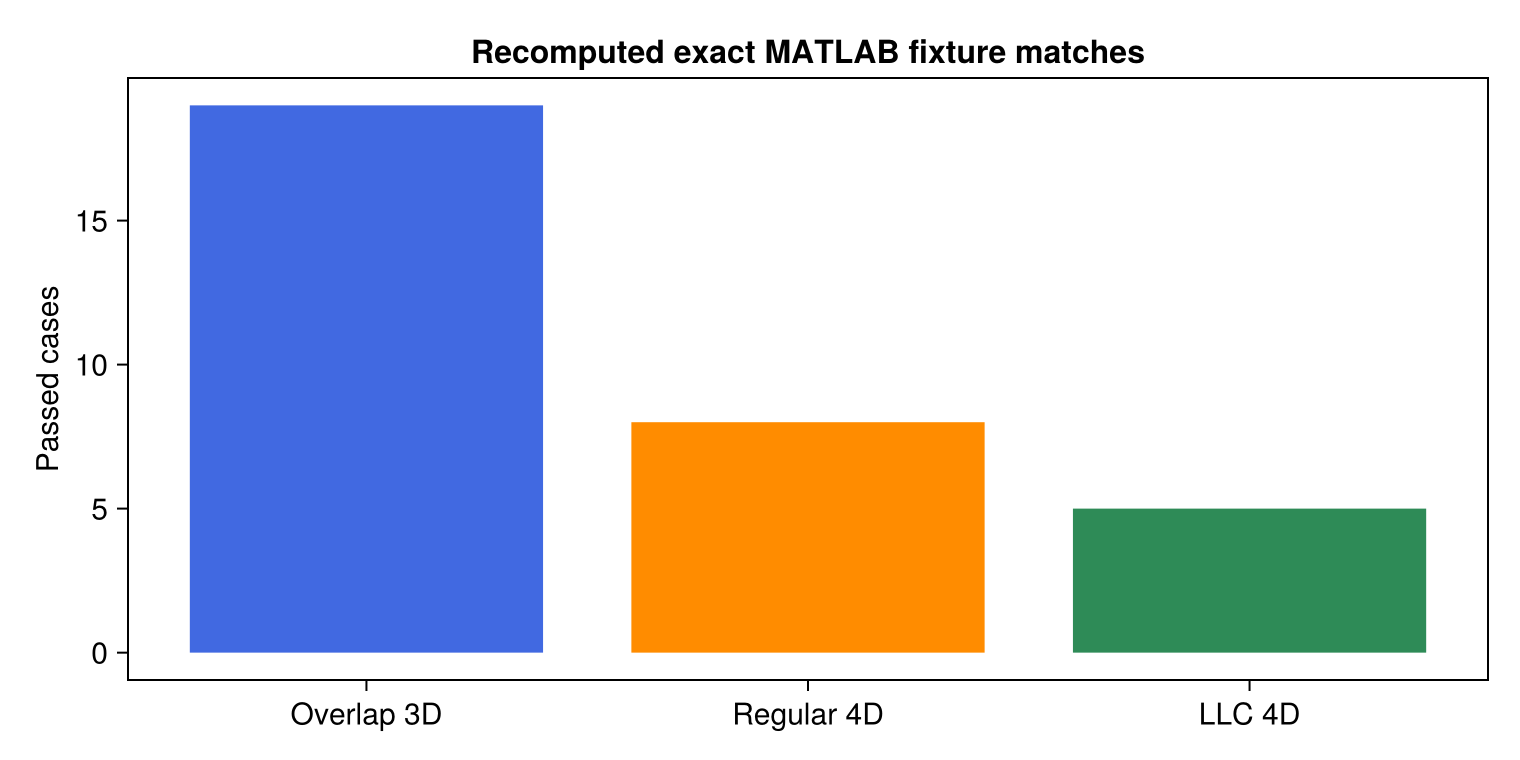

In [2]:
verified=Dict("Overlap 3D"=>0,"Regular 4D"=>0,"LLC 4D"=>0)
@testset "Recomputed exact MATLAB fixture comparisons" begin
    f=matread(joinpath(ROOT,"test","fixtures","overlap.mat"))
    for i in eachindex(f["inputs"])
        isempty(f["errors"][i]) || continue
        actual=track_mhw_3d(f["inputs"][i],vec(f["lon"]),vec(f["lat"]))
        expected=overlap_from_mat(f["outputs"][i])
        @test strict_overlap_equal(actual,expected)
        @test partition_equal(actual,expected,size(f["inputs"][i]))
        verified["Overlap 3D"]+=1
    end
    f=matread(joinpath(ROOT,"test","fixtures","lonlat4d.mat"))
    for i in eachindex(f["masks"])
        actual,_=track_mhw_4d_lonlat(f["masks"][i];min_duration=1)
        expected=indexed_from_mat(f["tracks"][i],4)
        @test strict_indexed_equal(actual,expected)
        @test partition_equal(actual,expected)
        verified["Regular 4D"]+=1
    end
    f=matread(joinpath(ROOT,"test","fixtures","llc4d.mat"))
    topology=LLCTopology(f["seamEdges"],(3,2,2))
    for i in eachindex(f["masks"])
        actual,_=track_mhw_4d_llc(f["masks"][i],topology;min_duration=1)
        expected=indexed_from_mat(f["tracks"][i],5)
        @test strict_indexed_equal(actual,expected)
        @test partition_equal(actual,expected)
        verified["LLC 4D"]+=1
    end
end
names=["Overlap 3D","Regular 4D","LLC 4D"]
fig=Figure(size=(760,380))
ax=Axis(fig[1,1],title="Recomputed exact MATLAB fixture matches",xticks=(1:3,names),ylabel="Passed cases")
barplot!(ax,1:3,[verified[n] for n in names];color=[:royalblue,:darkorange,:seagreen])
emit_figure(fig,"06_validation_cases")

## Recorded full real-data timings
Read `validation/results/real_metrics.txt` rather than rerunning the approximately 18-minute MATLAB reference inside this notebook. Notebook 02 contains the latest Julia remeasurement.
Both timings use the same positive mask and nums=4 overlap algorithm. Julia ARM64 and MATLAB x86_64 environments differ; these are local measurements, not a universal speedup claim.
Cumulative allocation is not peak memory. Maximum RSS describes the whole validation process, including loading, compilation, and result comparison.

Recorded real-data metrics: Dict

("active" => "1823266", "allocated_bytes" => "3207025184", "tracks_julia" => "4277", "julia_version" => "1.12.3", "shape" => "[400, 160, 731]", "tracks_matlab" => "4277", "event_partition_equal" => "true", "strict_fields_equal" => "true", "nums" => "4", "seconds" => "3.121914208", "matlab_seconds" => "1076.095594709")


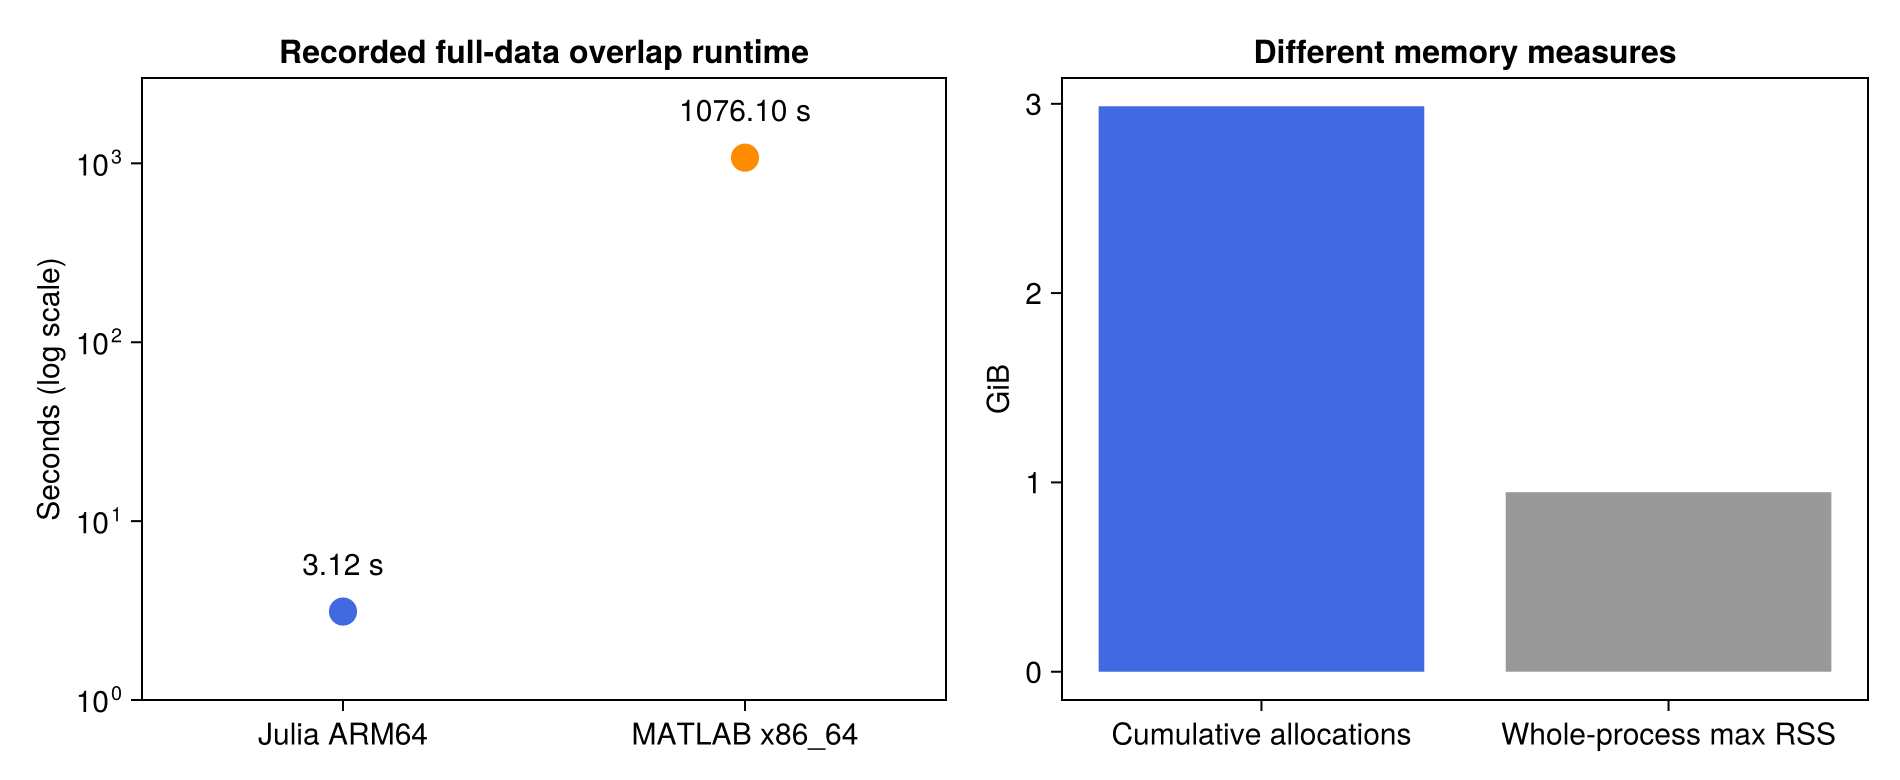

In [3]:
metricsfile=joinpath(ROOT,"validation","results","real_metrics.txt")
if isfile(metricsfile)
    metrics=read_metrics(metricsfile)
    @test metrics["strict_fields_equal"]=="true"
    @test metrics["event_partition_equal"]=="true"
    julia_seconds=parse(Float64,metrics["seconds"])
    matlab_seconds=parse(Float64,metrics["matlab_seconds"])
    println("Recorded real-data metrics: ",metrics)
    fig=Figure(size=(950,390))
    ax=Axis(fig[1,1],title="Recorded full-data overlap runtime",xticks=(1:2,["Julia ARM64","MATLAB x86_64"]),ylabel="Seconds (log scale)",yscale=log10)
    scatter!(ax,[1,2],[julia_seconds,matlab_seconds];color=[:royalblue,:darkorange],markersize=20)
    text!(ax,[1,2],[julia_seconds,matlab_seconds];text=[@sprintf("%.2f s",julia_seconds),@sprintf("%.2f s",matlab_seconds)],offset=(0,15),align=(:center,:bottom))
    xlims!(ax,0.5,2.5); ylims!(ax,1,3000)
    ax2=Axis(fig[1,2],title="Different memory measures",xticks=(1:2,["Cumulative allocations","Whole-process max RSS"]),ylabel="GiB")
    allocations=parse(Float64,metrics["allocated_bytes"])/2.0^30
    resourcefile=joinpath(ROOT,"validation","results","julia_real_resources.txt")
    resource=isfile(resourcefile) ? read(resourcefile,String) : ""
    m=match(r"(\d+)\s+maximum resident set size",resource)
    if m!==nothing
        rss=parse(Float64,m.captures[1])/2.0^30
        barplot!(ax2,[1,2],[allocations,rss];color=[:royalblue,:gray60])
    else
        barplot!(ax2,[1],[allocations];color=:royalblue)
        println("Max RSS not available from original process log.")
    end
    emit_figure(fig,"06_recorded_real_performance")
else
    println("NOT RUN: original full-data performance metrics are not present. See docs/performance.md.")
end

## Synthetic four-dimensional measurements in this environment
Use the same fixed random seed, dimensions, and sparse sampling as the standalone benchmark. Measure after warmup; current values may differ from the report's recorded run.
The workloads differ, so side-by-side plots report measurements rather than rank the algorithms. min_duration=1.

Regular shape: (

60, 30, 5, 12) | LLC logical shape: (90, 90, 13, 3, 12)
Current warm measurements: 

[(seconds = 0.000766792, bytes = 1715312, tracks = 1014), (seconds = 0.005603125, bytes = 6883840, tracks = 4808)]


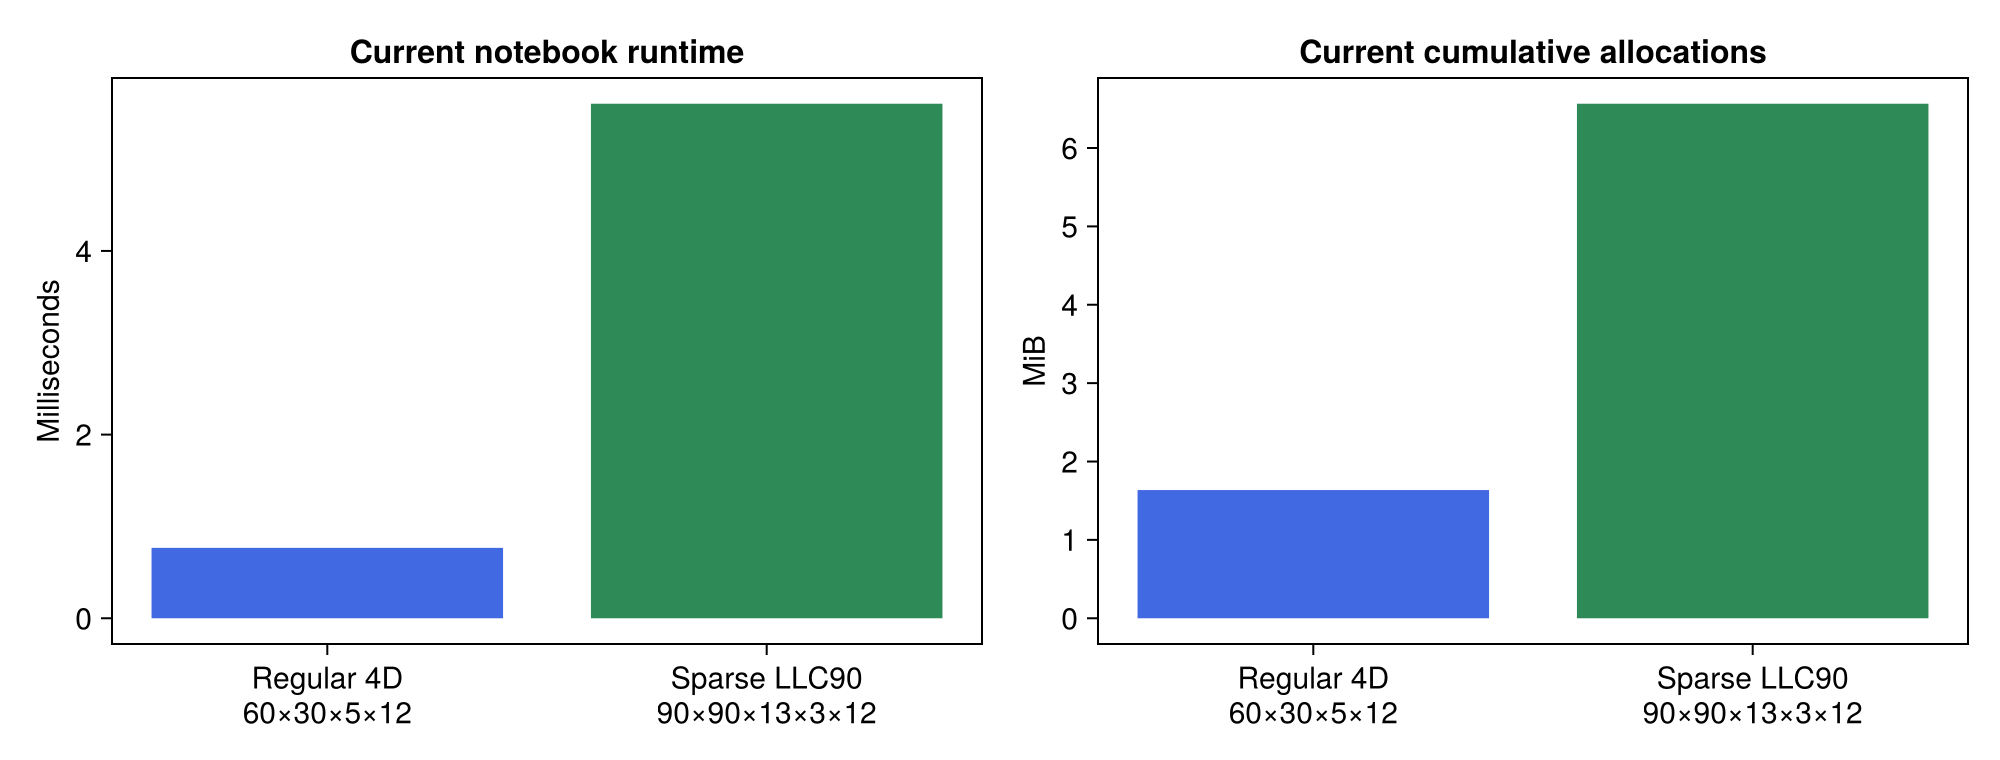

In [4]:
rng=MersenneTwister(20261008)
regular=rand(rng,60,30,5,12).<0.02
topology=load_seam_edges(joinpath(ROOT,"test","fixtures","llc90_topology.mat"))
dims=(topology.grid_size...,3,12)
sparse=SparseMask(dims,rand(rng,1:prod(dims),5000))
jobs=[()->track_mhw_4d_lonlat(regular;min_duration=1),
      ()->track_mhw_4d_llc(sparse,topology;min_duration=1)]
measurements=map(jobs) do job
    job(); GC.gc(); m=@timed job()
    (seconds=m.time,bytes=m.bytes,tracks=length(m.value[1]))
end
println("Regular shape: ",size(regular)," | LLC logical shape: ",dims)
println("Current warm measurements: ",measurements)
fig=Figure(size=(1000,380))
names=["Regular 4D\n60×30×5×12","Sparse LLC90\n90×90×13×3×12"]
ax=Axis(fig[1,1],title="Current notebook runtime",xticks=(1:2,names),ylabel="Milliseconds")
barplot!(ax,1:2,1000 .* getproperty.(measurements,:seconds);color=[:royalblue,:seagreen])
ax2=Axis(fig[1,2],title="Current cumulative allocations",xticks=(1:2,names),ylabel="MiB")
barplot!(ax2,1:2,getproperty.(measurements,:bytes)./2.0^20;color=[:royalblue,:seagreen])
emit_figure(fig,"06_current_4d_performance")

## Validation scope
- Standard package tests, full real three-dimensional field comparisons, exhaustive actual LLC seam tests, and auxiliary numeric checks have been executed.
- The standalone three-dimensional MATLAB file was not found; direct connectivity is labeled as an extension.
- No real production four-dimensional input is available; MATLAB four-dimensional comparisons use synthetic cases.
- Arbitrary cocircular points are not guaranteed to select the same Delaunay diagonal across library versions; tested spn samples passed.
- Run the full suite from the root with `julia --project=. -e 'using Pkg; Pkg.test()'`; figures do not replace automated tests.
Further details: `docs/validation_report.md`, `docs/performance.md`.